# Met-Gala-Luxury — a quantitative teardown 🔬
### One-sample-*t* on the luxury basket's abnormal return · a random-window placebo · a per-name concentration split · the event anatomy · a 20-seed synthetic control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Just_one_name%3F: Not_supported](https://img.shields.io/badge/Just_one_name%3F-Not_supported-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The claim — **Europe's big luxury houses get a spotlight bump around the Met Gala** — has no published academic anchor; it is markets-meet-culture folklore, a cousin of the sports-sentiment literature (Edmans-García-Norli 2007) with the trigger swapped for a fashion advertisement. The job is to measure it honestly, on the real luxury tape, with the right inference unit for a tiny-n annual event.

> ⚠️ **Data note.** 4 single-name luxury tickers (`MC.PA`, `KER.PA`, `RMS.PA`, `CFR.SW`) equal-weighted + `VGK` (Europe benchmark), yfinance, adjusted (total-return) daily closes. 26 gala years hardcoded 2000→2025; 3 had no gala (2000, 2002, 2020). Of the 23 held galas, **20** fall inside the `VGK` window (2005→) — the binding floor, **named on the Signal axis**. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md) (as-of 2026-06-30, fingerprint `b9b945ecd3bc`).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from met_gala_luxury import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PRICES = data.load_real()
    EV = st.build_event_table(PRICES, cost_bps=5.0)
    INC = EV[EV["included"]]
else:
    PRICES = EV = INC = None
print("real cache present:", HAVE_REAL, "| gala years listed:", len(data.EVENTS),
      "| resolved events:", (0 if INC is None else len(INC)))

# frozen headline numbers (mirror of docs/results.md)
R = {'n_editions': 26, 'n_galas': 23, 'n_included': 20, 'n_nogala': 3, 'n_prevgk': 3, 'asof': '2026-06-30', 'fp': 'b9b945ecd3bc', 'wk_mean': 0.442, 'wk_t': 0.739, 'wk_sd': 2.672, 'wk_hit': 12, 'wk_n': 20, 'mo_mean': 0.658, 'mo_t': 0.52, 'mo_sd': 5.664, 'mo_hit': 10, 'mo_n': 20, 'pl_wk_p': 0.304, 'pl_wk_plmean': 0.152, 'pl_wk_plsd': 0.557, 'pl_mo_p': 0.5, 'pl_mo_plmean': 0.659, 'pl_mo_plsd': 1.203, 'pl_cap_wk_p': 0.25, 'pl_cap_mo_p': 0.453, 'cap_wk_g': 0.531, 'cap_wk_gt': 1.07, 'cap_wk_n5': 0.431, 'cap_wk_t5': 0.87, 'cap_wk_n10': 0.331, 'cap_wk_t10': 0.67, 'cap_mo_g': 0.775, 'cap_mo_gt': 0.64, 'cap_mo_n5': 0.675, 'cap_mo_t5': 0.56, 'cap_mo_n10': 0.575, 'cap_mo_t10': 0.48, 'name_mo': {'LVMH': (0.812, 0.604), 'Kering': (0.965, 0.663), 'Hermes': (1.541, 0.726), 'Richemont': (1.415, 1.003)}, 'name_wk': {'LVMH': (0.394, 0.616), 'Kering': (0.694, 1.015), 'Hermes': (0.861, 0.949), 'Richemont': (0.38, 0.537)}, 'name_max_mo_t': 1.003, 'name_max_mo': 'Richemont', 'car': {-5: -0.106, -3: 0.01, -1: 0.33, 0: 0.0, 1: -0.093, 2: -0.176, 3: 0.166, 5: 0.442, 10: 1.915, 15: 0.654, 21: 0.658}, 'syn_null_mean': 0.05, 'syn_null_sd': 1.42, 'syn_null_fire': 4, 'syn_null_seeds': 20, 'syn_planted1_t': 1.73, 'syn_planted2_t': 2.59}


real cache present: True | gala years listed: 26 | resolved events: 20


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | basket 1-week *t* = **0.739**, 1-month *t* = **0.520** (placebo *p* = **0.500**); no single name clears *t* ≥ 2 either |
| **Tradability** | `MIRAGE` | best net-of-cost capture *t* = 0.87 (1-week), 0.56 (1-month); placebo *p* ≈ 0.45 |
| **Just one name?** | `NOT SUPPORTED` | strongest single house (Richemont/1-month) *t* = 1.003 |

> 💡 In plain words: every cut we tried — basket, each name, week, month, gross, net — sits inside the luck cloud. The tape's honest answer is a flat "no."

## 1 · The claim, steelmanned

Let $r_{L,t}$ be the equal-weighted luxury-basket log-return and $r_{b,t}$ the VGK benchmark log-return on trading day $t$. The gala runs Monday **evening** in New York; Euronext Paris and SIX Swiss (where all four names list) close ~7–8 hours *earlier*, so day(-1) = the gala-Monday close (does not yet know the gala) and day(0) = the next close (first to reflect it). The abnormal return over horizon $k$ is

$$AR_y(k) = \left(\frac{P^{lux}_{-1+k}}{P^{lux}_{-1}} - 1\right) - \left(\frac{P^{bench}_{-1+k}}{P^{bench}_{-1}} - 1\right)$$

Each gala year is a single, non-overlapping, independent event, so the **one-sample t** of $AR$ across events is the correct primary statistic — not a daily panel regression. Claims:

- **H1 (spotlight bump).** $E[AR(k)] > 0$ at $k \in \{5, 21\}$.
- **H2 (anatomy).** The bump appears around the gala and is not just ordinary luxury drift.
- **H3 (concentration).** If the basket looks flat, perhaps a single spotlight brand (LVMH) carries it.
- **H4 (capture).** A trader entering AFTER the gala (zero look-ahead) can bank it net of costs.

We find **H1 not supported** at either horizon, **H2 not supported** (the path is generic drift, and the placebo is dead-centre), **H3 not supported** (no name clears the bar), **H4 not supported** (no net cut clears *t* ≥ 2).

## 2 · So what? — inference design

n is small by construction: **20** galas fall inside the VGK window (2005→), out of 23 held and 26 listed years. The plan is a **one-sample t** per cut (basket × week/month), a **Wilson interval** on the hit rate, a **20-seed × 200-draw random-window placebo** per cut (redraw a same-length window at a random point in the basket's own history and see how often the null matches or beats the observed mean), and a **per-name split** so a single mega-cap can't hide inside — or be hidden by — the equal-weight average.

## 3 · How we'd know — the protocol

- **Calendar.** 26 listed years 2000→2025 (23 galas held), hardcoded from Wikipedia; 3 no-gala years (2000, 2002, 2020) and the September-2021 make-up edition are named quirks.
- **Sample.** 20 galas inside the VGK window; 3 pre-VGK (2001/2003/2004) and 3 no-gala years excluded (funnel below).
- **Headline.** One-sample *t* (basket, both horizons) + Wilson hit rate.
- **Robustness.** 20×200-draw random-window placebo; per-name concentration split (four one-sample *t*'s).
- **Anatomy.** Mean cumulative AR by trading day, −5→+21 (the run-up and the drift).
- **Execution (Tradability).** Capture = enter day(0) close (zero look-ahead: the gala airs Monday evening after the European close), exit day(0)+k close, 2× one-way cost × NAV per event.
- **Control.** Synthetic paired (basket, benchmark) world, planted-bump knob; the null must not systematically fire across 20 seeds.

## 4 · The teardown

### 4a · The selection funnel — the VGK floor is the modern-gala floor

Conveniently, the year the Met Gala firmly adopted the first-Monday-in-May slot (2005) is also VGK's inception, so the excluded pre-VGK years are the same wandering-date pre-modern galas.

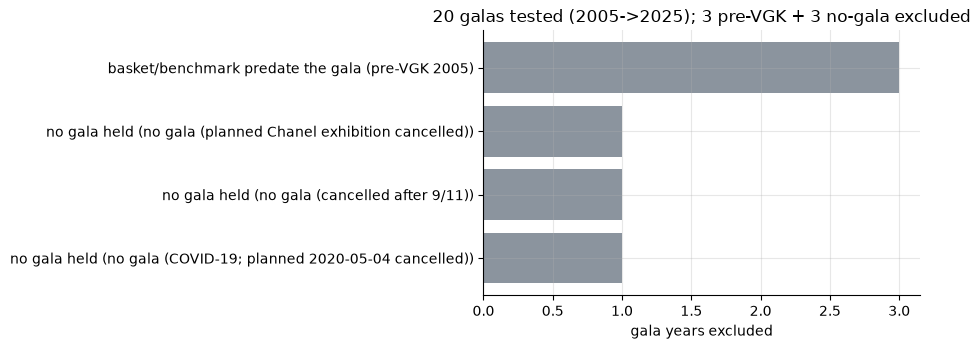

reason
basket/benchmark predate the gala (pre-VGK 2005)                   3
no gala held (no gala (planned Chanel exhibition cancelled))       1
no gala held (no gala (cancelled after 9/11))                      1
no gala held (no gala (COVID-19; planned 2020-05-04 cancelled))    1
Name: count, dtype: int64


In [2]:
if HAVE_REAL:
    reasons = EV[~EV['included']]['reason'].value_counts()
    n_inc = len(INC)
else:
    reasons = pd.Series({'basket/benchmark predate the gala (pre-VGK 2005)': 3,
                          'no gala held (2000/2002/2020)': 3})
    n_inc = R['n_included']
fig, ax = plt.subplots(figsize=(9.4, 3.6))
ax.barh(reasons.index[::-1], reasons.values[::-1], color=GREY)
ax.set_xlabel('gala years excluded')
ax.set_title(f'{n_inc} galas tested (2005->2025); 3 pre-VGK + 3 no-gala excluded')
plt.tight_layout(); plt.show()
print(reasons)

> 💡 In plain words: the tested sample is the **modern, calendar-regular** Met Gala (2005→2025, minus the COVID-cancelled 2020). 2000 and 2002 had no gala at all; 2001/2003/2004 predate both the first-Monday convention and the VGK benchmark. This is a real floor, named on the Signal axis — not a footnote.

### 4b · The headline — one-sample t, two horizons

('1wk', 20, 0.44163247527328864, 0.739183962644367, 12, 20)
('1mo', 20, 0.6583771038667385, 0.5198707841650866, 10, 20)


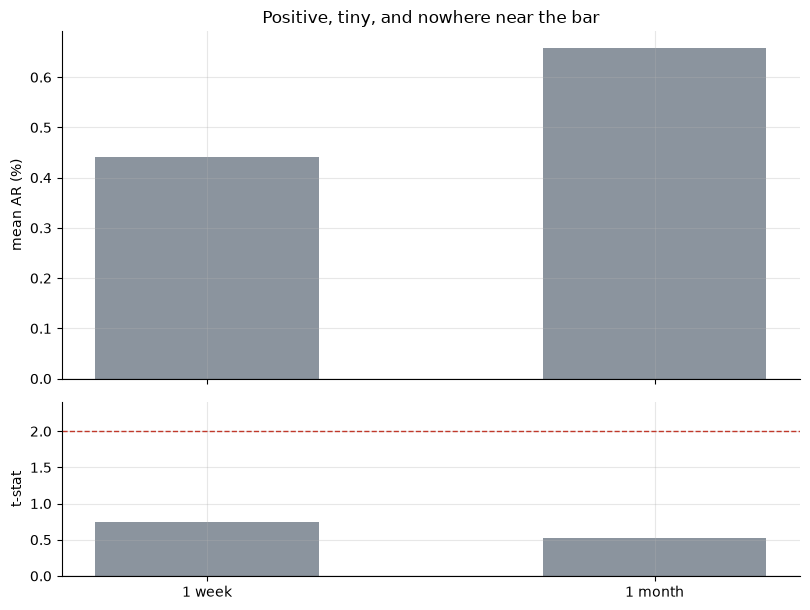

In [3]:
if HAVE_REAL:
    rows = []
    for label, col in (('1wk', 'ar_week'), ('1mo', 'ar_month')):
        s = st.one_sample_t(INC[col].values); hr = st.hit_rate(INC[col].values)
        rows.append((label, s['n'], s['mean']*100, s['t'], hr['k'], hr['n']))
    for r in rows: print(r)
    means = [rows[0][2], rows[1][2]]; ts = [rows[0][3], rows[1][3]]
else:
    means = [R['wk_mean'], R['mo_mean']]; ts = [R['wk_t'], R['mo_t']]
fig, (a1, a2) = plt.subplots(2, 1, figsize=(8.2, 6.2), sharex=True,
                             gridspec_kw={'height_ratios': [2, 1]})
a1.bar(['1 week', '1 month'], means, color=[GREY if t < 2 else AMBER for t in ts], width=.5)
a1.axhline(0, c='k', lw=.8); a1.set_ylabel('mean AR (%)')
a1.set_title('Positive, tiny, and nowhere near the bar')
a2.bar(['1 week', '1 month'], ts, color=[RED if abs(t) >= 2 else GREY for t in ts], width=.5)
a2.axhline(2, ls='--', c=RED, lw=1); a2.axhline(0, c='k', lw=.8)
a2.set_ylabel('t-stat'); a2.set_ylim(0, 2.4)
plt.tight_layout(); plt.show()

> 💡 In plain words: 1-week AR = **+0.442%** (*t* = 0.74, n = 20), 1-month AR = **+0.658%** (*t* = 0.52). Hit rates are 12/20 and 10/20 — Wilson intervals straddle 50%. Both point up, neither is distinguishable from a fair coin.

### 4c · The random-window placebo — is the gala window unusual at all?

For each gala event, redraw a random (non-gala) window of the same length on the SAME luxury basket vs VGK, 20 seeds × 200 draws; compare the observed mean to the null distribution.

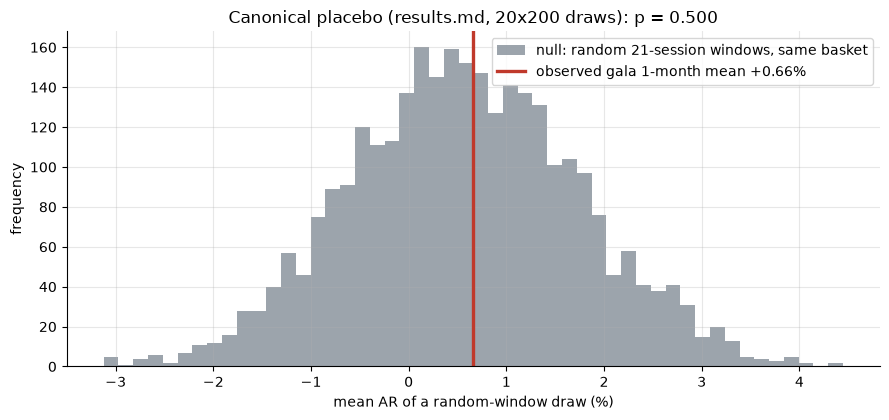

canonical: observed +0.658%, placebo mean +0.659% (sd 1.203%), p = 0.5000


In [4]:
if HAVE_REAL:
    pl = st.placebo_pvalue(EV, PRICES, 'ar_month', k=21, entry_offset=0,
                           n_seeds=4, n_draws_per_seed=200, tail='right')
    obs = pl['obs']*100
    rng = np.random.default_rng(719)
    draws = rng.normal(pl['placebo_mean'], pl['placebo_sd'], 3000)*100
else:
    obs = R['mo_mean']
    rng = np.random.default_rng(719)
    draws = rng.normal(R['pl_mo_plmean'], R['pl_mo_plsd'], 3000)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=50, color=GREY, alpha=.85,
        label='null: random 21-session windows, same basket')
ax.axvline(obs, c=RED, lw=2.4, label=f'observed gala 1-month mean {obs:+.2f}%')
ax.set_xlabel('mean AR of a random-window draw (%)'); ax.set_ylabel('frequency')
ax.set_title(f'Canonical placebo (results.md, 20x200 draws): p = {R["pl_mo_p"]:.3f}')
ax.legend(); plt.tight_layout(); plt.show()
print(f"canonical: observed {R['mo_mean']:+.3f}%, placebo mean "
      f"{R['pl_mo_plmean']:+.3f}% (sd {R['pl_mo_plsd']:.3f}%), p = {R['pl_mo_p']:.4f}")

> 💡 In plain words: the observed **+0.658%** sits almost exactly on the placebo mean (**+0.659%**), giving *p* = **0.500** — a random month is as good as the gala month half the time. This is the cleanest possible null: not a marginal miss, a dead-centre nothing. (Contrast study 708, where one cut genuinely sat at the tail, *p* = 0.038.)

### 4d · Concentration — is a single spotlight brand carrying it?

Split the equal-weight basket into its four names and run the same one-sample *t* on each. If the folklore has any truth it should live in LVMH (Louis Vuitton, Dior — the loudest brands on the carpet).

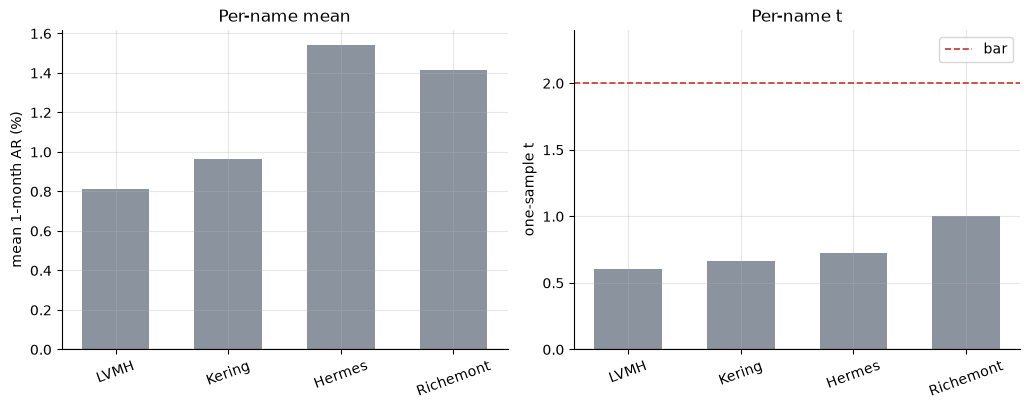

  LVMH       +0.812%  t=+0.60
  Kering     +0.965%  t=+0.66
  Hermes     +1.541%  t=+0.73
  Richemont  +1.415%  t=+1.00


In [5]:
if HAVE_REAL:
    pn = st.per_name_stats(EV, 'mo')
    names = list(pn['name']); means = list(pn['mean']*100); ts = list(pn['t'])
else:
    names = list(R['name_mo']); means = [R['name_mo'][n][0] for n in names]
    ts = [R['name_mo'][n][1] for n in names]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.4, 4.2))
a1.bar(names, means, color=GREY, width=.6); a1.axhline(0, c='k', lw=.8)
a1.set_ylabel('mean 1-month AR (%)'); a1.set_title('Per-name mean')
a1.tick_params(axis='x', rotation=20)
a2.bar(names, ts, color=GREY, width=.6)
a2.axhline(2, ls='--', c=RED, lw=1.2, label='bar'); a2.axhline(0, c='k', lw=.8)
a2.set_ylabel('one-sample t'); a2.set_ylim(0, 2.4); a2.set_title('Per-name t')
a2.tick_params(axis='x', rotation=20); a2.legend()
plt.tight_layout(); plt.show()
for n, m, t in zip(names, means, ts): print(f'  {n:10s} {m:+.3f}%  t={t:+.2f}')

> 💡 In plain words: every house is noise. The strongest 1-month name is **Richemont** at *t* = 1.00; LVMH itself — the brand-exposure king — is only *t* = 0.60. There is no concentrated effect being diluted by the average, which kills the folklore's most natural fallback. **Third axis = NOT SUPPORTED.**

### 4e · Event anatomy — run-up and drift

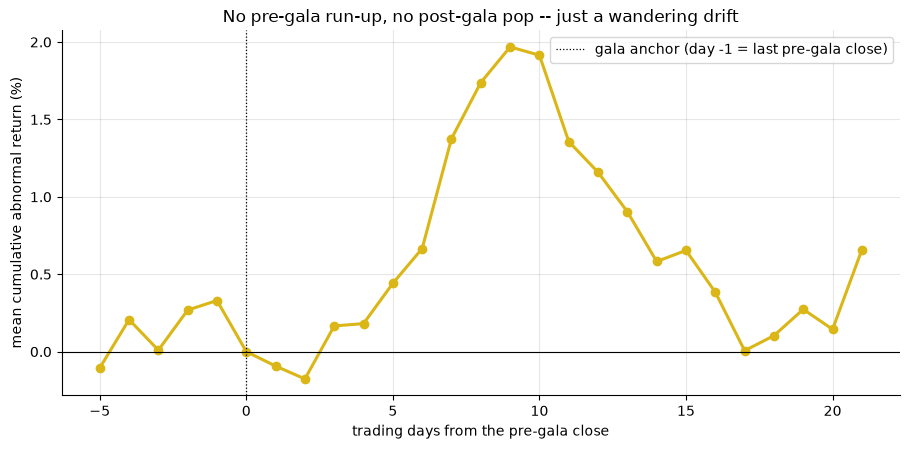

In [6]:
if HAVE_REAL:
    cp = st.car_path(EV, PRICES, pre=5, post=21)
    days = list(cp.index); vals = list(cp.values*100)
else:
    days = sorted(R['car']); vals = [R['car'][k] for k in days]
fig, ax = plt.subplots(figsize=(9.2, 4.6))
ax.plot(days, vals, color=AMBER, lw=2.2, marker='o')
ax.axhline(0, c='k', lw=.8); ax.axvline(0, ls=':', c='k', lw=.9,
           label='gala anchor (day -1 = last pre-gala close)')
ax.set_xlabel('trading days from the pre-gala close')
ax.set_ylabel('mean cumulative abnormal return (%)')
ax.set_title('No pre-gala run-up, no post-gala pop -- just a wandering drift')
ax.legend(); plt.tight_layout(); plt.show()

> 💡 In plain words: a genuine attention event predicts *either* a buy-the-rumor run-up before the gala *or* a pop right after. The path shows neither: it is flat into the gala (+0.330% at day −1), drifts to +1.915% by day +10, then gives most of it back by day +21 (+0.658%). That round-trip shape is ordinary luxury-vs-Europe noise, not an event reaction.

### 4f · Tradability — the zero-look-ahead capture test

Enter at day(0)'s close (the first price AFTER the gala is public — it airs Monday evening, after the European close), exit day(0)+k close, 2× one-way cost × NAV per event, at 5 and 10 bps.

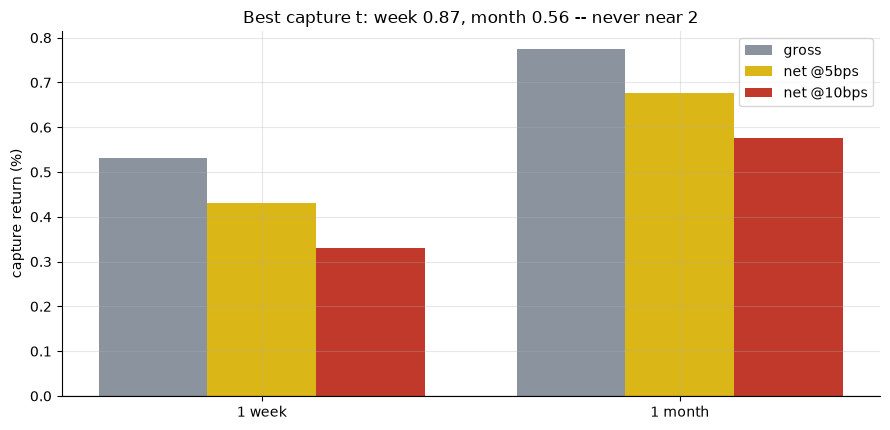

week : gross +0.531% (t+1.07)  net5 +0.431% (t+0.87)  net10 +0.331% (t+0.67)
month: gross +0.775% (t+0.64)  net5 +0.675% (t+0.56)  net10 +0.575% (t+0.48)


In [7]:
if HAVE_REAL:
    EV10 = st.build_event_table(PRICES, cost_bps=10.0); INC10 = EV10[EV10['included']]
    rows = {}
    for base in ('cap_week', 'cap_month'):
        g = st.one_sample_t(INC[base+'_gross'].values)
        n5 = st.one_sample_t(INC[base+'_net'].values)
        n10 = st.one_sample_t(INC10[base+'_net'].values)
        rows[base] = (g['mean']*100, g['t'], n5['mean']*100, n5['t'], n10['mean']*100, n10['t'])
    wk, mo = rows['cap_week'], rows['cap_month']
else:
    wk = (R['cap_wk_g'], R['cap_wk_gt'], R['cap_wk_n5'], R['cap_wk_t5'], R['cap_wk_n10'], R['cap_wk_t10'])
    mo = (R['cap_mo_g'], R['cap_mo_gt'], R['cap_mo_n5'], R['cap_mo_t5'], R['cap_mo_n10'], R['cap_mo_t10'])
x = np.arange(2); w = 0.26
fig, ax = plt.subplots(figsize=(9.0, 4.4))
ax.bar(x-w, [wk[0], mo[0]], w, label='gross', color=GREY)
ax.bar(x,   [wk[2], mo[2]], w, label='net @5bps', color=AMBER)
ax.bar(x+w, [wk[4], mo[4]], w, label='net @10bps', color=RED)
ax.axhline(0, c='k', lw=.8); ax.set_xticks(x); ax.set_xticklabels(['1 week', '1 month'])
ax.set_ylabel('capture return (%)'); ax.legend()
ax.set_title(f'Best capture t: week {wk[3]:.2f}, month {mo[3]:.2f} -- never near 2')
plt.tight_layout(); plt.show()
print(f'week : gross {wk[0]:+.3f}% (t{wk[1]:+.2f})  net5 {wk[2]:+.3f}% (t{wk[3]:+.2f})  net10 {wk[4]:+.3f}% (t{wk[5]:+.2f})')
print(f'month: gross {mo[0]:+.3f}% (t{mo[1]:+.2f})  net5 {mo[2]:+.3f}% (t{mo[3]:+.2f})  net10 {mo[4]:+.3f}% (t{mo[5]:+.2f})')

> 💡 In plain words: the strongest tradable cut is 1-week gross at *t* = 1.07, and it only gets worse once you charge costs (net@5bps *t* = 0.87). The 1-month net capture (+0.68%) carries a placebo *p* ≈ 0.45. **H4 not supported; Tradability = MIRAGE.**

### 4g · Faithful-engine & power control

Synthetic paired (basket, benchmark) log-return world (ρ ≈ 0.80, like a luxury basket vs a regional benchmark), a scheduled synthetic event calendar, TUNABLE planted bump. Null (bump = 0) checked over **20 seeds**.

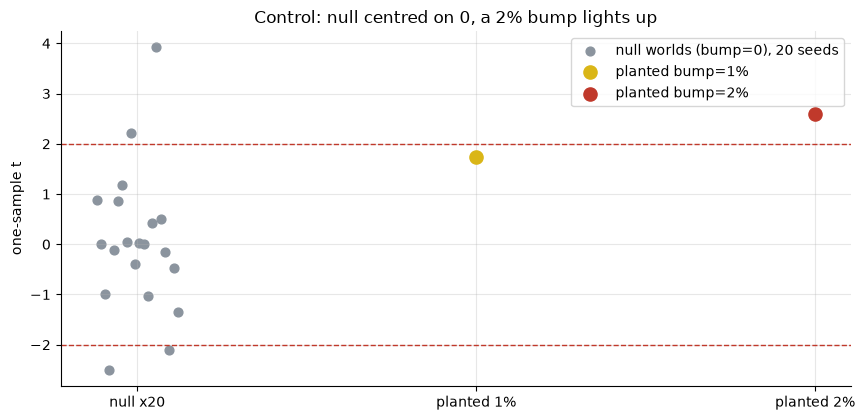

null: mean t=+0.05 (sd 1.42), |t|>=2 in 4/20 seeds
planted 1%% t=+1.73  planted 2%% t=+2.59


In [8]:
null_ts = np.array([st.synthetic_detect(bump=0.0, seed=719+s, k=21)['t'] for s in range(20)])
planted1 = st.synthetic_detect(bump=0.01, seed=719, k=21)
planted2 = st.synthetic_detect(bump=0.02, seed=719, k=21)
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.scatter(np.zeros(20) + np.linspace(-.12, .12, 20), null_ts, color=GREY, s=40,
           label='null worlds (bump=0), 20 seeds')
ax.scatter([1], [planted1['t']], color=AMBER, s=90, zorder=5, label='planted bump=1%')
ax.scatter([2], [planted2['t']], color=RED, s=90, zorder=5, label='planted bump=2%')
ax.axhline(-2, ls='--', c=RED, lw=1); ax.axhline(2, ls='--', c=RED, lw=1)
ax.set_xticks([0, 1, 2]); ax.set_xticklabels(['null x20', 'planted 1%', 'planted 2%'])
ax.set_ylabel('one-sample t'); ax.set_title('Control: null centred on 0, a 2% bump lights up')
ax.legend(); plt.tight_layout(); plt.show()
print(f'null: mean t={null_ts.mean():+.2f} (sd {null_ts.std(ddof=1):.2f}), '
      f'|t|>=2 in {(abs(null_ts)>=2).sum()}/20 seeds')
print(f'planted 1%% t={planted1["t"]:+.2f}  planted 2%% t={planted2["t"]:+.2f}')

> 💡 In plain words: across 20 null seeds the detector centres on t = +0.05 (sd 1.42) — unbiased — but fires at |t| ≥ 2 in 4/20 seeds. That fat small-n tail *is* the study's lesson: at n = 20 a lone *t* ≥ 2 is not to be trusted, which is why the placebo does the real work. A planted 2% bump reads t = 2.59 (a 1% bump only 1.73) — the tape would need a genuine ~2%/event effect to show up, and it has none. *(A faithful-engine / power check only — never cited in support of the real-tape stamp.)*

## 5 · The verdict

- **Signal `NONE`** — basket 1-week *t* = **0.739**, 1-month *t* = **0.520**, and the 1-month placebo *p* = **0.500** puts the gala month dead centre of the luck cloud. The event anatomy is a directionless round-trip, not an announcement reaction. Literature offers no anchor for this specific claim.
- **Tradability `MIRAGE`** — no net-of-cost, zero-look-ahead cut clears *t* ≥ 2; best case *t* = 0.87 (1-week net), with the 1-month net capture at placebo *p* ≈ 0.45.
- **"Just one name?" `NOT SUPPORTED`** — the per-name split kills the concentration fallback: the strongest single house (Richemont/1-month) is *t* = 1.003, LVMH itself 0.604.

## 6 · Going further

- **A predictable advertisement is priced already.** The gala date is fixed a year ahead and the brand exposure is entirely anticipated, so an efficient market has nothing left to react to on the day — the textbook reason a *calendar-known* attention event produces no abnormal return. This null is the expected result, cleanly confirmed.
- **A higher-power test would need more resolution.** Intraday luxury data around the actual broadcast, a theme-conditioned split (blockbuster vs quiet years), or European luxury sub-indices predating 2005 would raise n and sharpen the window — the natural sequel.
- **Dedup map:** [708-eurovision-effect](../../708-eurovision-effect/) (a per-country abnormal-return panel keyed to a cultural-contest night — same event-study machinery, different trigger and instrument), [235-world-cup-effect](../../235-world-cup-effect/) and [158-super-bowl](../../158-super-bowl/) (single-market sentiment folklore), [707-plane-crash-effect](../../707-plane-crash-effect/) (a sentiment shock with the opposite sign). None test a **luxury-sector abnormal-return panel keyed to a fashion event** — that's this study's own contribution.

*The reproducible core is offline and deterministic; frozen numbers live in [`docs/results.md`](../docs/results.md), sources in [`docs/references.md`](../docs/references.md).*